# Disease Prediction from Medical Data
**Dataset:** Pima Indians Diabetes Dataset  
**Models:** Logistic Regression, SVM, Random Forest, XGBoost  
**Goal:** Predict whether a patient has diabetes based on medical features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Dataset Info:')
print(df.info())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
print('Missing Values:')
print(df.isnull().sum())

print('\nClass Distribution:')
print(df['Outcome'].value_counts())
print(f"Non-Diabetic: {df['Outcome'].value_counts()[0]} | Diabetic: {df['Outcome'].value_counts()[1]}")

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Non-Diabetic: 500 | Diabetic: 268


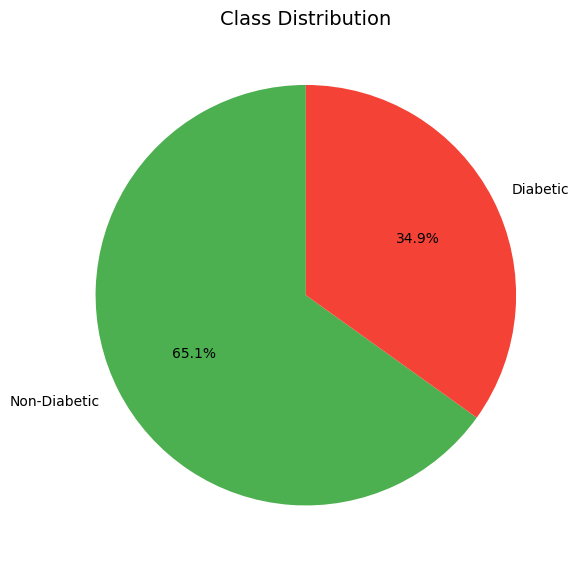

In [5]:
# Class distribution pie chart
plt.figure(figsize=(6, 6))
df['Outcome'].value_counts().plot.pie(
    labels=['Non-Diabetic', 'Diabetic'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)
plt.title('Class Distribution', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

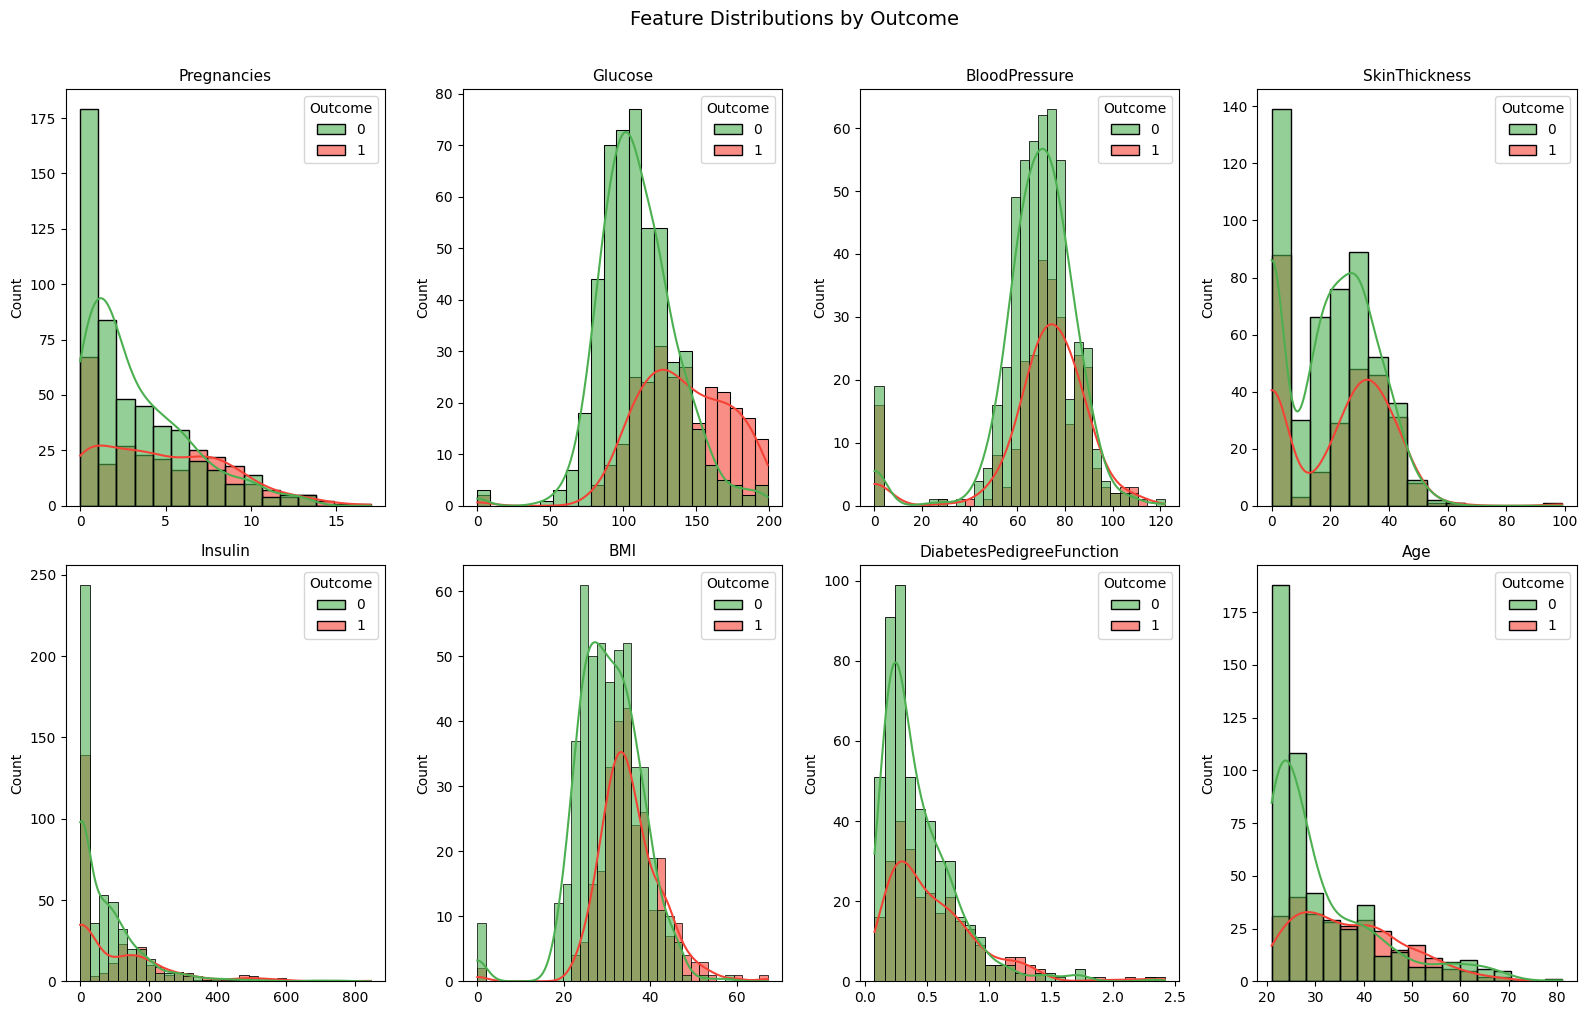

In [6]:
# Feature distributions
plt.figure(figsize=(16, 10))
features = df.columns[:-1]
for i, col in enumerate(features):
    plt.subplot(2, 4, i+1)
    sns.histplot(data=df, x=col, hue='Outcome', kde=True,
                 palette=['#4CAF50', '#F44336'], alpha=0.6)
    plt.title(col, fontsize=11)
    plt.xlabel('')
plt.suptitle('Feature Distributions by Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

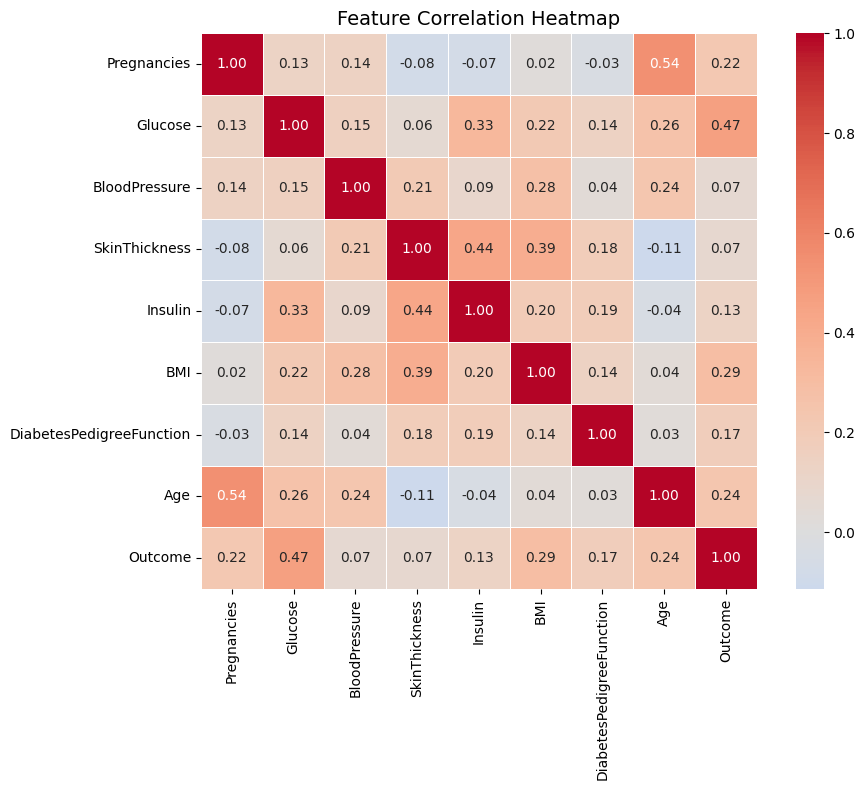

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [8]:
# Columns where 0 means missing data (not biologically possible)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with column median
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

print('Zero values replaced with median.')
print(df.describe())

Zero values replaced with median.
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      27.334635   94.652344   
std       3.369578   30.438286      12.096642       9.229014  105.547598   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      23.000000   30.500000   
50%       3.000000  117.000000      72.000000      23.000000   31.250000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.450911                  0.471876   33.240885    0.348958  
std      6.875366                  0.331329   11.760232    0.476951  
m

In [9]:
# Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 614
Testing samples:  154


In [10]:
# Feature scaling — bring all features to same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled successfully.')

Features scaled successfully.


In [11]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM':                 SVC(probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred)  * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred)    * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred)        * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba)  * 100, 2),
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }
    print(f'{name} trained.')

Logistic Regression trained.
SVM trained.
Random Forest trained.
XGBoost trained.


In [12]:
# Comparison table
metrics_df = pd.DataFrame({
    name: {
        k: v for k, v in vals.items()
        if k in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
    }
    for name, vals in results.items()
}).T

print('\n===== Model Comparison (%) =====')
print(metrics_df.to_string())


===== Model Comparison (%) =====
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     70.78      60.00   50.00     54.55    81.52
SVM                     73.38      64.44   53.70     58.59    79.39
Random Forest           75.97      68.09   59.26     63.37    82.00
XGBoost                 74.03      64.00   59.26     61.54    80.93


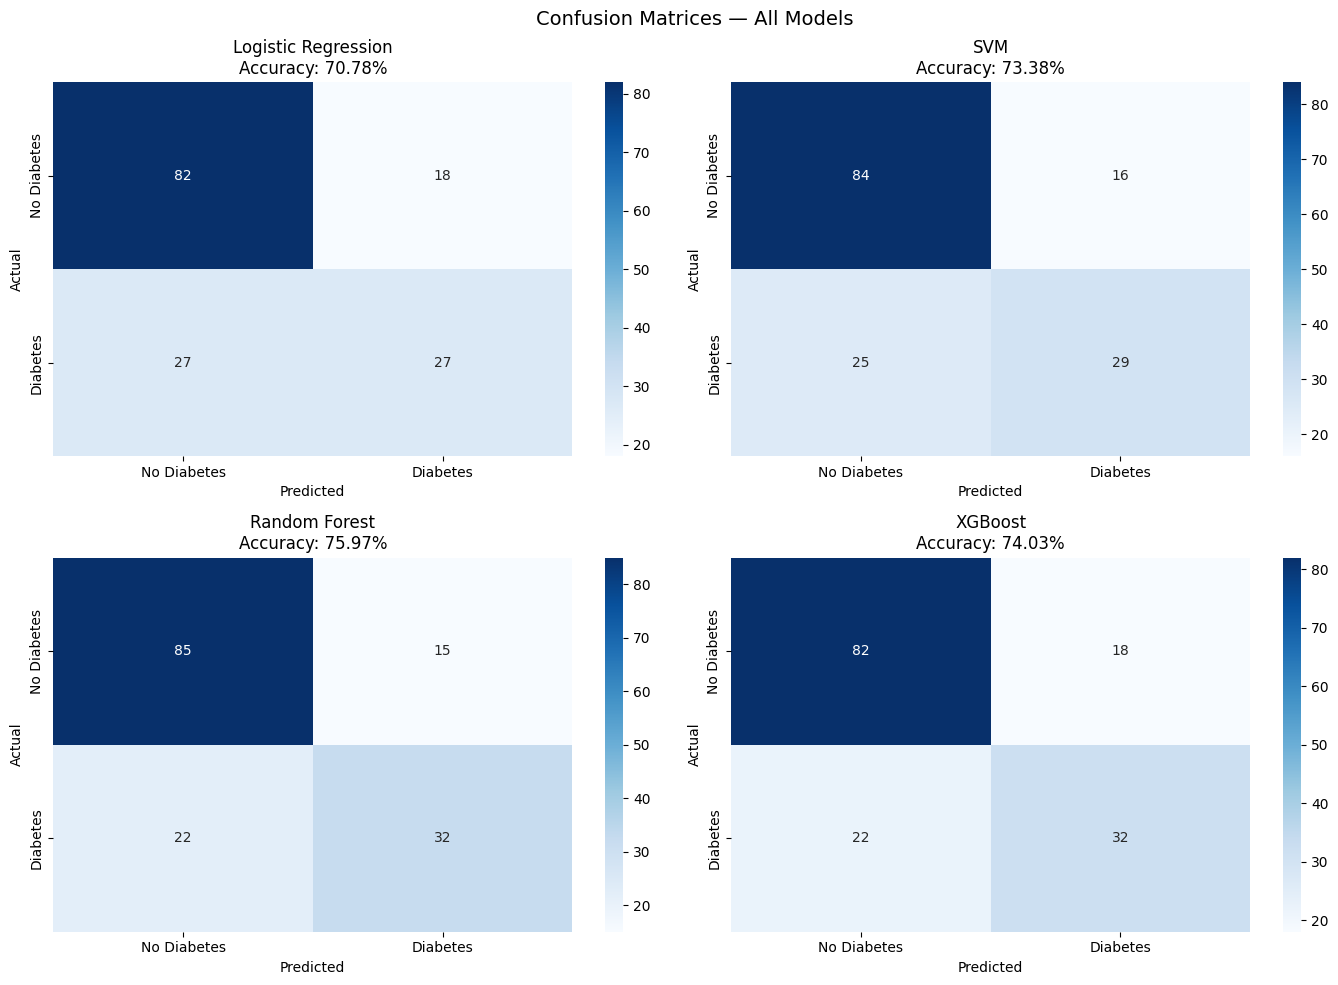

In [13]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, vals) in enumerate(results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Diabetes','Diabetes'],
                yticklabels=['No Diabetes','Diabetes'],
                ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {vals["Accuracy"]}%', fontsize=12)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

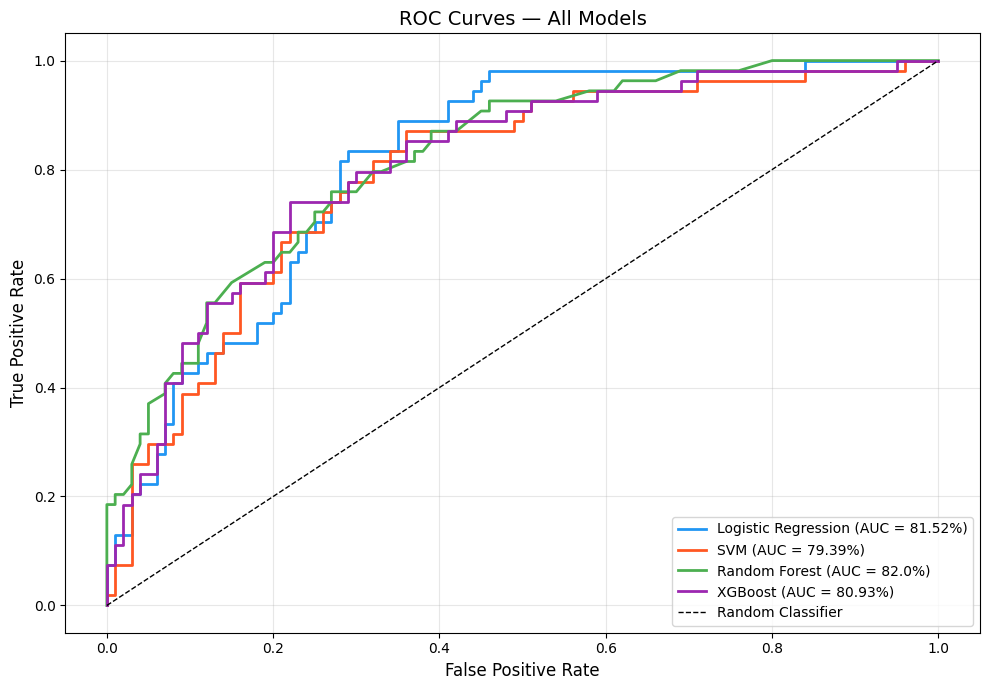

In [14]:
# ROC Curves
plt.figure(figsize=(10, 7))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for (name, vals), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, vals['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {vals['ROC-AUC']}%)")

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

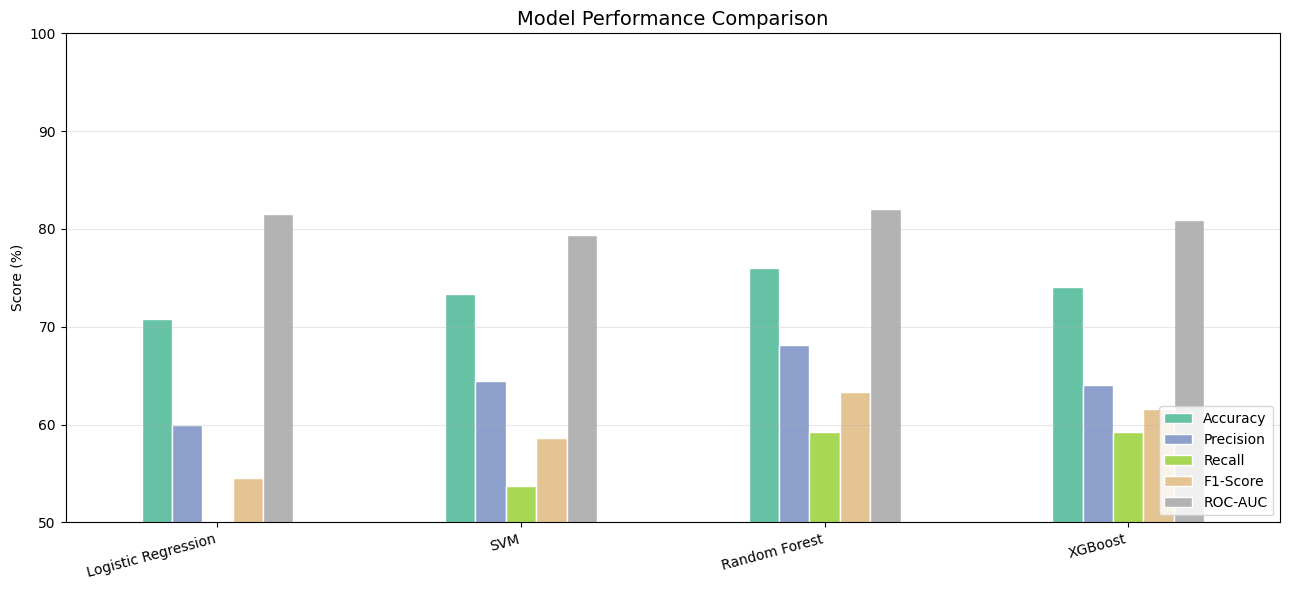

In [15]:
# Metrics bar chart comparison
metrics_plot = metrics_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
metrics_plot.plot(kind='bar', figsize=(13, 6), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score (%)')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.ylim(50, 100)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

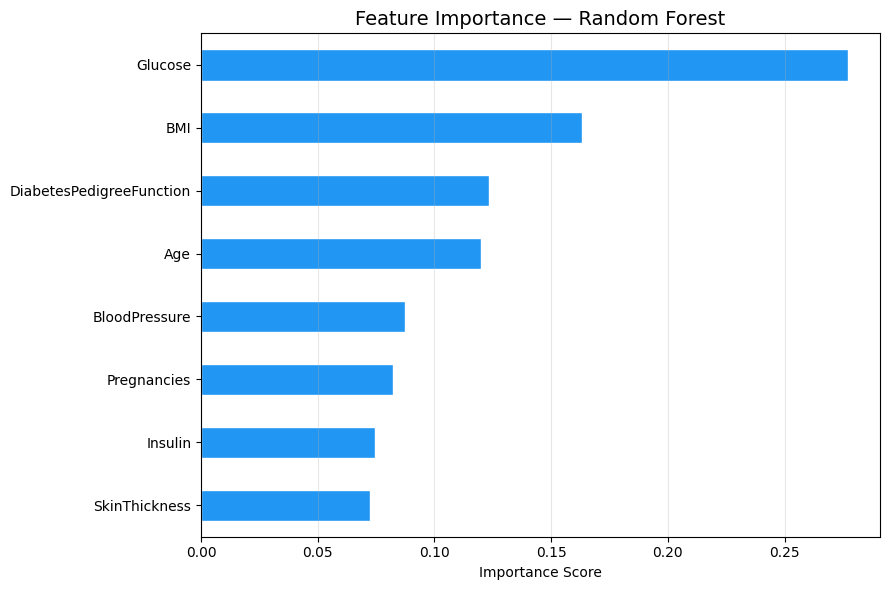

In [16]:
# Feature importance from Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='#2196F3', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [17]:
# Find best model by ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
print(f'Best Model: {best_model_name}')
print(f'ROC-AUC:    {results[best_model_name]["ROC-AUC"]}%')
print(f'Accuracy:   {results[best_model_name]["Accuracy"]}%')
print(f'F1-Score:   {results[best_model_name]["F1-Score"]}%')

Best Model: Random Forest
ROC-AUC:    82.0%
Accuracy:   75.97%
F1-Score:   63.37%


In [18]:
# Predict for a new patient
# Format: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_patient_scaled = scaler.transform(new_patient)

best_model = results[best_model_name]['model']
prediction = best_model.predict(new_patient_scaled)[0]
probability = best_model.predict_proba(new_patient_scaled)[0][1]

print(f'\nPatient Data: {new_patient[0]}')
print(f'Prediction:   {"DIABETIC" if prediction == 1 else "NOT DIABETIC"}')
print(f'Probability of Diabetes: {probability*100:.1f}%')


Patient Data: [  6.    148.     72.     35.      0.     33.6     0.627  50.   ]
Prediction:   DIABETIC
Probability of Diabetes: 86.0%
